## Step 1: Import common Python packages

In [5]:
import os
import openpyxl
import pandas as pd
import numpy as np
import sklearn

## Step 2: Setup working directory

In [6]:
os.chdir('/Users/markruperto/Desktop/School/GCU/BIT-456/Topic 2 - Support Vector Machine')

In [7]:
os.getcwd()

'/Users/markruperto/Desktop/School/GCU/BIT-456/Topic 2 - Support Vector Machine'

## Step 3: Import data

In [8]:
lattes = pd.read_excel('Lattes2.xlsx', sheet_name='TrainTestData')

In [9]:
lattes.head()

,Record,Age,EstMonthsCustomer,EstSalary,LatteDonut
0,1,26,7,46502,0
1,2,58,17,92946,1
2,3,36,1,59027,1
3,4,66,18,92321,1
4,5,59,18,97795,1


## Step 4: Determine the counts for each category of the "LatteDonut" variable

In [10]:
lattes['LatteDonut'].value_counts(dropna=False)

LatteDonut
0    360
1    190
Name: count, dtype: int64

## Step 5: Define weeklydata to specify the features and the target variable

In [11]:
feature_columns = ['Age', 'EstMonthsCustomer', 'EstSalary']

x = lattes[feature_columns]
y = lattes.LatteDonut

print(feature_columns)

['Age', 'EstMonthsCustomer', 'EstSalary']


## Step 6: X and Y into training and testing sets (70/30) split

In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

## Step 7: Create an SVM Classifier

In [29]:
from sklearn import svm

clf = svm.SVC(
    kernel='rbf',
    probability=True, #Required to run probability on visualization
    random_state=42)

In [19]:
 print(clf.get_params())

{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': 'deprecated', 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


## Step 8: Train the model

In [30]:
clf.fit(x_train, np.ravel(y_train, order='C'))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


## Step 9: Perform cross-validation on training dataset using 4 splits

In [31]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

kfold = KFold(n_splits=4) #splits data into 4 equal folds
cv_results = cross_val_score(clf, x_train, np.ravel(y_train, order='C'), cv=kfold, scoring='accuracy') #handles scoring and fitting

print("Cross-validation accuracy:", cv_results)
print("Mean accuracy:", cv_results.mean())

Cross-validation accuracy: [0.87628866 0.84375    0.88541667 0.88541667]
Mean accuracy: 0.8727179982817869


/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. 

## Step 10: Predict reponses for test data 

In [33]:
y_pred = clf.predict(x_test)

print(y_pred)

[0 0 0 1 1 0 0 0 0 1 1 0 1 1 0 0 0 0 0 1 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 1 0 1 0 1 0 1 0 1 1 1 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 1 1 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1]


## Step 11: Create a confusion matrix for the model

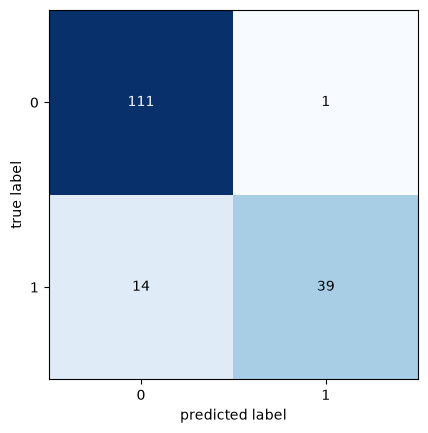

In [25]:
from sklearn.metrics import confusion_matrix
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred) #compares actual test labels against the model's predictions and builds the matrix
fig, ax = plot_confusion_matrix(conf_mat=cm) #renders the matrix as a labeled, color-coded heatmap
plt.show()

## Step 12: Create visualizations related to model performance using kds package:

LABELS INFO:

 prob_min         : Minimum probability in a particular decile
 prob_max         : Minimum probability in a particular decile
 prob_avg         : Average probability in a particular decile
 cnt_events       : Count of events in a particular decile
 cnt_resp         : Count of responders in a particular decile
 cnt_non_resp     : Count of non-responders in a particular decile
 cnt_resp_rndm    : Count of responders if events assigned randomly in a particular decile
 cnt_resp_wiz     : Count of best possible responders in a particular decile
 resp_rate        : Response Rate in a particular decile [(cnt_resp/cnt_cust)*100]
 cum_events       : Cumulative sum of events decile-wise 
 cum_resp         : Cumulative sum of responders decile-wise 
 cum_resp_wiz     : Cumulative sum of best possible responders decile-wise 
 cum_non_resp     : Cumulative sum of non-responders decile-wise 
 cum_events_pct   : Cumulative sum of percentages of events decile-wise 
 cum_resp_pct     : Cu

/opt/anaconda3/lib/python3.13/site-packages/kds/metrics.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dt = df.groupby('decile').apply(lambda x: pd.Series([
/opt/anaconda3/lib/python3.13/site-packages/kds/metrics.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dt = df.groupby('decile').apply(lambda x: pd.Series([
/opt/anaconda3/lib/python3.13/site-packages/kds/metrics.py:85: FutureWarning: DataFrameGroupBy

,decile,prob_min,prob_max,prob_avg,cnt_cust,cnt_resp,cnt_non_resp,cnt_resp_rndm,cnt_resp_wiz,resp_rate,cum_cust,cum_resp,cum_resp_wiz,cum_non_resp,cum_cust_pct,cum_resp_pct,cum_resp_pct_wiz,cum_non_resp_pct,KS,lift
0,1,0.913,0.941,0.929,17.0,17.0,0.0,5.3,17,100.000,17.0,17.0,17,0.0,10.303,32.075,32.075,0.000,32.075,3.113
1,2,0.871,0.913,0.898,16.0,15.0,1.0,5.3,16,93.750,33.0,32.0,33,1.0,20.000,60.377,62.264,0.893,59.484,3.019
2,3,0.201,0.864,0.495,17.0,12.0,5.0,5.3,17,70.588,50.0,44.0,50,6.0,30.303,83.019,94.340,5.357,77.662,2.740
3,4,0.151,0.200,0.165,16.0,2.0,14.0,5.3,3,12.500,66.0,46.0,53,20.0,40.000,86.792,100.000,17.857,68.935,2.170
4,5,0.144,0.150,0.146,17.0,2.0,15.0,5.3,0,11.765,83.0,48.0,53,35.0,50.303,90.566,100.000,31.250,59.316,1.800
5,6,0.137,0.143,0.140,16.0,1.0,15.0,5.3,0,6.250,99.0,49.0,53,50.0,60.000,92.453,100.000,44.643,47.810,1.541
6,7,0.130,0.137,0.134,17.0,1.0,16.0,5.3,0,5.882,116.0,50.0,53,66.0,70.303,94.340,100.000,58.929,35.411,1.342
7,8,0.126,0.129,0.128,16.0,0.0,16.0,5.3,0,0.000,132.0,50.0,53,82.0,80.000,94.340,100.000,73.214,21.126,1.179
8,9,0.124,0.126,0.125,17.0,2.0,15.0,5.3,0,11.765,149.0,52.0,53,97.0,90.303,98.113,100.000,86.607,11.506,1.086
9,10,0.122,0.124,0.123,16.0,1.0,15.0,5.3,0,6.250,165.0,53.0,53,112.0,100.000,100.000,100.000,100.000,0.000,1.000


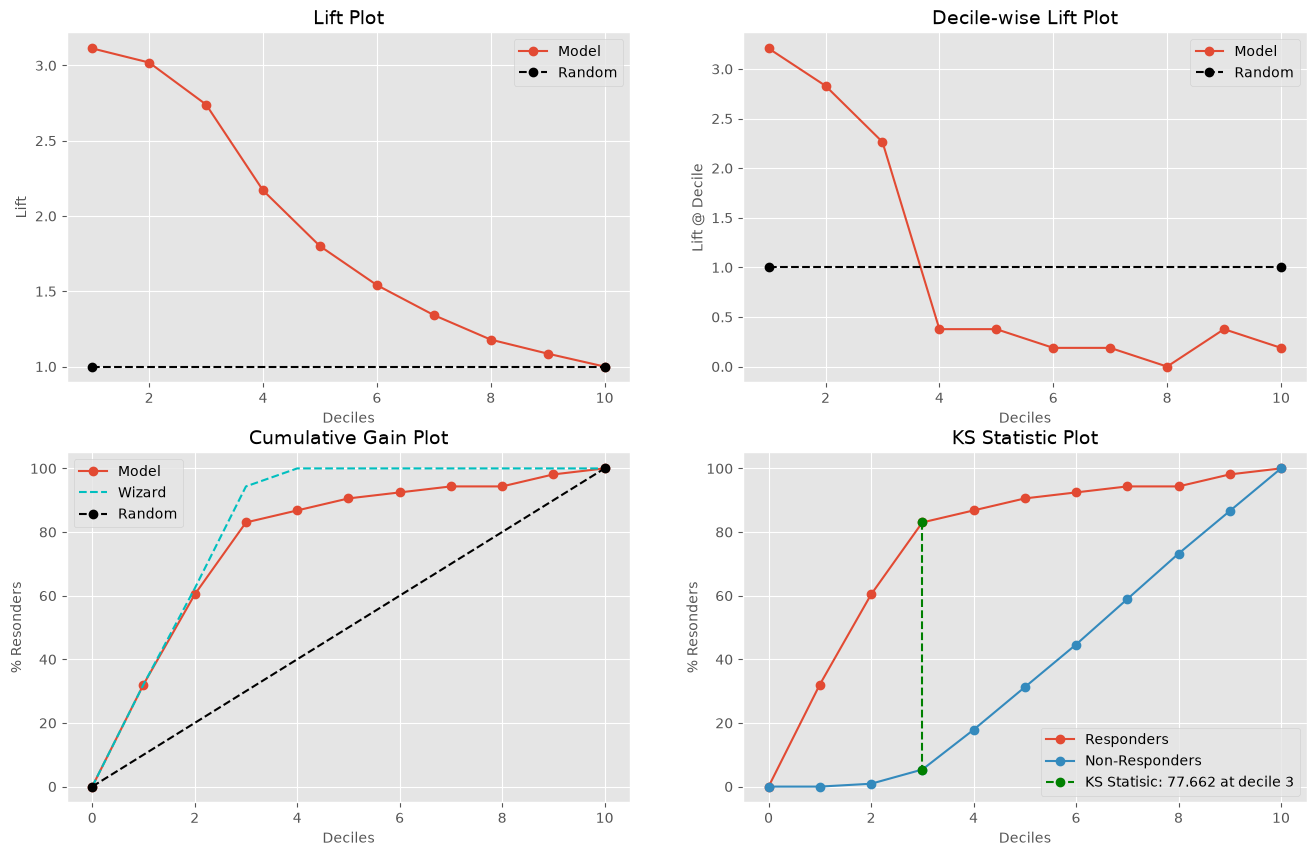

In [34]:
import kds

y_test_series = y_test.squeeze()
y_prob = clf.predict_proba(x_test)[:, 1]

kds.metrics.report(y_test_series, y_prob, plot_style='ggplot')

## Step 13: Create an ROC chart for "y_test" and "y_pred"

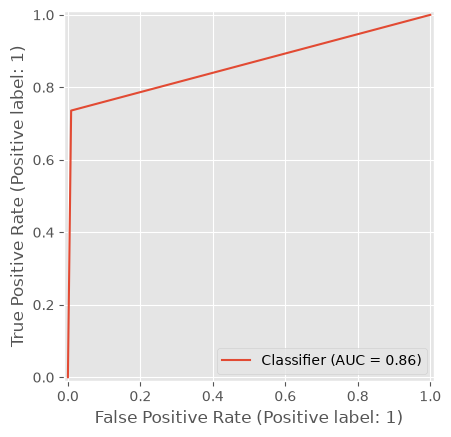

In [35]:
from sklearn.metrics import RocCurveDisplay

#This shows the tradeoff between the true positive rate and false positive rate 
#along with the AUC (Area Under the Curve) score
#the closer AUC is to 1.0, the better the model discriminates between classes.

RocCurveDisplay.from_predictions(y_test, y_pred)
plt.show()

## Step 14: Calculate comprehensive metrics for model using "from sklearn import metrics"

In [38]:
from sklearn import metrics

y_prob = clf.predict_proba(x_test)[:, 1]

accuracy = metrics.accuracy_score(y_test, y_pred)
f1_macro = metrics.f1_score(y_test, y_pred, average='macro')
f1_micro = metrics.f1_score(y_test, y_pred, average='micro')
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
hamming = metrics.hamming_loss(y_test, y_pred)
jaccard = metrics.jaccard_score(y_test, y_pred)
logloss = metrics.log_loss(y_test, y_prob)
zero_one = metrics.zero_one_loss(y_test, y_pred)
roc_auc = metrics.roc_auc_score(y_test, y_prob)
mcc = metrics.matthews_corrcoef(y_test, y_pred)

print(f"Accuracy:              {accuracy:.4f}")
print(f"F1 Score (Macro):      {f1_macro:.4f}")
print(f"F1 Score (Micro):      {f1_micro:.4f}")
print(f"Precision Score:       {precision:.4f}")
print(f"Recall Score:          {recall:.4f}")
print(f"Hamming Loss:          {hamming:.4f}")
print(f"Jaccard Score:         {jaccard:.4f}")
print(f"Log Loss:              {logloss:.4f}")
print(f"Zero-One Loss:         {zero_one:.4f}")
print(f"ROC AUC Score:         {roc_auc:.4f}")
print(f"Matthews Corrcoef:     {mcc:.4f}")

Accuracy:              0.9091
F1 Score (Macro):      0.8877
F1 Score (Micro):      0.9091
Precision Score:       0.9750
Recall Score:          0.7358
Hamming Loss:          0.0909
Jaccard Score:         0.7222
Log Loss:              0.2902
Zero-One Loss:         0.0909
ROC AUC Score:         0.9132
Matthews Corrcoef:     0.7920


## Step 15: Predict the responses for new dataset

In [40]:
new_data = pd.read_excel("Lattes2.xlsx", sheet_name="NewData")

new_data["Prediction"] = clf.predict(new_data.drop(columns=["Record"]))

new_data.to_excel("Lattes2Predictions.xlsx", index=False)

In [41]:
print(new_data)

    Record  Age  EstMonthsCustomer  EstSalary  Prediction
0        1   26                 11      68523           0
1        2   58                 23      52331           0
2        3   33                 22      88986           1
3        4   34                  3      57489           0
4        5   35                 10      82224           1
..     ...  ...                ...        ...         ...
95      96   48                 16      96229           1
96      97   53                 14      59264           0
97      98   63                  7      55633           0
98      99   52                 20      74202           0
99     100   33                 11      97951           1

[100 rows x 5 columns]


In [42]:
print(os.path.exists("Lattes2Predictions.xlsx"))

True


## Step 16: Conclusion